<a href="https://colab.research.google.com/github/leesuyee/dynamic-routing-tutorials/blob/main/code/Intro-Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention and Sensory Processing

**University of Puget Sound NRSC 490 · Advanced Topics in Neuroscience**

**Su-Yee Lee**

**Resources**:

[Allen Neural Dynamics data portal](https://data.allenneuraldynamics-test.org/view?asset=ecephys_713655_2024-08-09_10-41-47_nwb_2026-08-04_15-02-39&subject_id=713655&unit_id=713655_2024-08-09_C-362)

[SWDB Data Book](https://allenswdb.github.io/physiology/ephys/dynamic-routing/dynamic-routing-background.html)

## Learning objectives

- Open and navigate an NWB file — the standard format for shared neural data
- Plot neural activity as both discrete spikes (raster) and a continuous firing rate
- Build a peri-stimulus time histogram (PSTH) to visualize event-triggered responses
- Compare PSTHs across stimuli to characterize a neuron's stimulus tuning
- Classify neurons based on stimulus response profiles
- Quantify context-dependent changes in neural activity using an Attention Modulation Index (AMI)

---
## Setup

In [1]:
# Run once on Colab
!pip -q install numpy==2.1.3 pandas==2.2.3 matplotlib==3.10 scipy==1.16.3 zarr==2.18.7 aiohttp==3.14.3 hdmf_zarr==0.13.0 s3fs==2026.7.0

# Get units table data for example session from Github Release
!mkdir -p /content/data
!wget -q -P /content/data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/713655-units-data/713655_2024-08-09.parquet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from hdmf_zarr import NWBZarrIO
import os

plt.rcParams['figure.dpi'] = 110

---
## 1. Load an NWB session

Each recording session is stored as an **NWB Zarr** file on a public S3 bucket. Below is a list of all the S3 paths to the data available for this tutorial. To access the data, we'll use NWBZarrIO to stream the file from S3.

In [3]:
S3_PATHS = [
    "s3://aind-open-data/ecephys_708016_2024-04-29_12-59-12_nwb_2026-08-04_15-02-46/708016_2024-04-29.nwb.zarr",
    "s3://aind-open-data/ecephys_741137_2024-10-10_13-15-50_nwb_2026-08-04_15-10-12/741137_2024-10-10.nwb.zarr",
    "s3://aind-open-data/ecephys_715710_2024-07-16_12-58-34_nwb_2026-08-04_15-11-54/715710_2024-07-16.nwb.zarr",
    "s3://aind-open-data/ecephys_713655_2024-08-09_10-41-47_nwb_2026-08-04_15-02-39/713655_2024-08-09.nwb.zarr",
    "s3://aind-open-data/ecephys_714748_2024-06-24_12-52-23_nwb_2026-08-04_15-06-39/714748_2024-06-24.nwb.zarr",
    "s3://aind-open-data/ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/759434_2025-02-04.nwb.zarr",
    "s3://aind-open-data/ecephys_742903_2024-10-23_14-12-23_nwb_2026-08-04_15-14-57/742903_2024-10-23.nwb.zarr",
    "s3://aind-open-data/ecephys_664851_2023-11-16_12-54-53_nwb_2026-08-04_15-09-33/664851_2023-11-16.nwb.zarr",
    "s3://aind-open-data/ecephys_662892_2023-08-24_14-28-28_nwb_2026-08-04_15-13-29/662892_2023-08-24.nwb.zarr",
    "s3://aind-open-data/ecephys_712815_2024-05-22_12-26-32_nwb_2026-08-04_14-59-22/712815_2024-05-22.nwb.zarr",
    "s3://aind-open-data/ecephys_743199_2024-12-05_12-42-34_nwb_2026-08-04_15-00-49/743199_2024-12-05.nwb.zarr",
    "s3://aind-open-data/ecephys_667252_2023-09-28_15-00-38_nwb_2026-08-04_15-21-37/667252_2023-09-28.nwb.zarr",
]

# Pick one session for the whole tutorial.
s3_path = S3_PATHS[3]      # 713655_2024-08-09

io = NWBZarrIO(path=s3_path, mode='r', storage_options={'anon': True})
nwbfile = io.read()
nwbfile

# takes ~4m to load

/usr/local/lib/python3.13/dist-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (460263, 500) float32 read-only>
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (460280, 500) float32 read-only>
  warnings.warn(


,timestamps
id,
0,NaN
1,14.17525
2,14.19192
3,14.20858
,timestamps
id,
0,NaN
1,14.40125
2,14.41791


### Open an NWB File

The data for each experimental session is stored as a **[Neurodata Without Borders (NWB)](https://www.nwb.org)** file. NWB is a community standard for physiology data capable of storing neural activity (spikes, fluorescence traces), behavior, stimulus tables, and metadata in one file using a hierarchical layout (like folders in a file system).

For this tutorial, we'll use:
- `units` — every recorded neuron (spike times, brain area, QC, waveform metrics, …)
- `intervals` — trial and epoch tables which report information about the behavior task (stimulus times, stimulus type, outcomes)

---
## 2. The `units` table

Neural activity data is stored in the `units` table. Each row in `units` is one putative neuron. Loading the full table takes several minutes (on Colab can take up to 20m), so we'll the filtered version of the table that we loaded into this workspace at the top to speed things up.

| Column Name | Definition |
|---|---|
| `unit_id` | unique identifier for the unit |
| `stim_start_time` | array with time (seconds) that this unit fired an action potential |
| `rewarded_modality` | boolean that determines whether this unit passed QC filtering |

**Important Note:** to save time, we've downloaded a filtered units table for this example from Github. this table contains select columns and only units that pass qc, so everything in this columns should equal True. to see how to load the full units table from the NWB file (all units, all columns) or pre-generated filtered units tables for other sessions, see the commented out code cells below.

In [4]:
units = pd.read_parquet('/content/data/713655_2024-08-09.parquet')
units.head()

,unit_id,spike_times,structure,is_qc_pass
3,713655_2024-08-09_A-3,"[21.589898466019914, 25.376921105508842, 26.38...",AV,True
6,713655_2024-08-09_A-8,"[20.5297681262966, 20.66936773209339, 20.76706...",AV,True
9,713655_2024-08-09_A-11,"[20.66703440534894, 20.68156769764297, 21.0538...",AV,True
16,713655_2024-08-09_A-19,"[20.2972354495921, 20.38506853490121, 20.39233...",AV,True
31,713655_2024-08-09_A-35,"[234.5388304713543, 307.03232576326747, 468.94...",AD,True


Other options for loading units table:

If you want to load the full units table from the NWB file, use the following code. Note that this can take ~20m on Google Colab to fully run. I recommend doing this once and saving the data as a parquet file afterwards to load locally later on.

In [ ]:
## Load pre-filtered units table for other sessions from Github Release (not used in this tutorial)

# !mkdir -p data
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/662892_2023-08-24.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/664851_2023-11-16.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/667252_2023-09-28.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/708016_2024-04-29.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/712815_2024-05-22.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/713655_2024-08-09.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/714748_2024-06-24.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/715710_2024-07-16.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/741137_2024-10-10.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/742903_2024-10-23.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/743199_2024-12-05.parquet
# !wget -q -P data https://github.com/leesuyee/dynamic-routing-tutorials/releases/download/all-units-data/759434_2025-02-04.parquet
#
# units_table = pd.read_parquet("data/708016_2024-04-29.parquet")  # example of how to load one of the files

In [ ]:
## Load full units table and all columns - (takes >20m to load)

# units_full = nwbfile.units[:]
# print(nwbfile.units.colnames)

In [ ]:
## Another option - load select columns but all units - (takes ~20m to load)

# units_select_columns = pd.DataFrame({
#     'unit_id':     nwbfile.units['unit_id'][:],
#     'spike_times': nwbfile.units['spike_times'][:],
#     'structure':   nwbfile.units['structure'][:],
#     'is_qc_pass':  nwbfile.units['is_qc_pass'][:],
# })

In [5]:
# Check total number of units in this session
print('Total units:', len(units))

Total units: 1185


In [6]:
# How many QC-pass units did we record in each brain area? (top 15)
(units[units['is_qc_pass']]
   .groupby('structure').size()
   .sort_values(ascending=False))


# Resource: https://atlas.brain-map.org/
# Check out the Adult Mouse Brain Atlas to see the full name of each structure and where it is located in the brain

,0
structure,
SSs,209
ECT,168
LSr,144
MOp,134
CP,105
MOs,95
AUDp,87
TEa,77
AUDv,62


---
## 3. Pick one neuron

Let's select a neuron to plot - how would we find a neuron in primary auditory cortex (AUDp) and passes QC?

In [7]:
# Exercise:

audp_units = units[(units['is_qc_pass'] == True ) & (units['structure'] == 'AUDp')]
audp_units

,unit_id,spike_times,structure,is_qc_pass
1237,713655_2024-08-09_C-298,"[38.987480845555226, 68.24799277869838, 76.546...",AUDp,True
1238,713655_2024-08-09_C-299,"[20.317397984014693, 20.498862864177497, 20.59...",AUDp,True
1239,713655_2024-08-09_C-300,"[33.368769494548175, 37.967457554250686, 52.68...",AUDp,True
1240,713655_2024-08-09_C-302,"[20.495062901587755, 20.705627495266743, 21.00...",AUDp,True
1244,713655_2024-08-09_C-306,"[20.320331288469934, 20.327964546654595, 20.33...",AUDp,True
...,...,...,...,...
1927,713655_2024-08-09_C-1030,"[24.83105354752042, 30.07976854110515, 30.1459...",AUDp,True
1929,713655_2024-08-09_C-1032,"[20.295398200600395, 25.048584739280603, 29.53...",AUDp,True
1931,713655_2024-08-09_C-1034,"[53.40377225192015, 60.81379930093399, 93.5845...",AUDp,True
1933,713655_2024-08-09_C-1036,"[47.631929075147504, 47.939126050823546, 49.32...",AUDp,True


There are a few ways to select a neuron - by its unit_id or by indexing into the row. Here, we've pre-selected a good example neuron by its unit_id but you can also index into the row.

In [8]:
unit_id     = '713655_2024-08-09_C-388'
unit_row    = units.loc[units['unit_id'] == unit_id].iloc[0]
area        = unit_row['structure']
spike_times = np.asarray(unit_row['spike_times'])

print(f'unit_id : {unit_id}')
print(f'area    : {area}')
print(f'# spikes: {len(spike_times):,}')

unit_id : 713655_2024-08-09_C-388
area    : AUDp
# spikes: 41,909


---
## 4. Plot spike times and firing rate for a selected neuron

Spike times reports the list of times when the unit fired an action potential. We can create a raster plot by plotting each spike as a tick mark over time.

### 4.1 Raster: every spike in the session

Each vertical tick = one spike/action potential

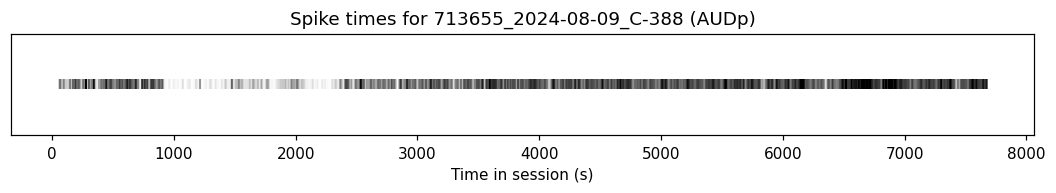

In [9]:
plt.figure(figsize=(12, 1.2))
plt.plot(spike_times, np.zeros_like(spike_times), '|', color='k', alpha=0.01)
plt.yticks([])
plt.xlabel('Time in session (s)')
plt.title(f'Spike times for {unit_id} ({area})')
plt.show()

### 4.2 Convert to a firing rate

Individual spikes are hard to read at this scale. Convert to a **firing rate**: count spikes in short bins, divide by bin width to get Hz.

The function below `firing_rate` will convert spike times to firing_rate.

In [10]:
def firing_rate(spike_times, bin_size=1.0):
    """Bin spikes across the session and convert counts to Hz."""
    bin_edges     = np.arange(spike_times[0], spike_times[-1] + bin_size, bin_size)
    spike_counts, _ = np.histogram(spike_times, bins=bin_edges)
    return bin_edges[:-1], spike_counts / bin_size

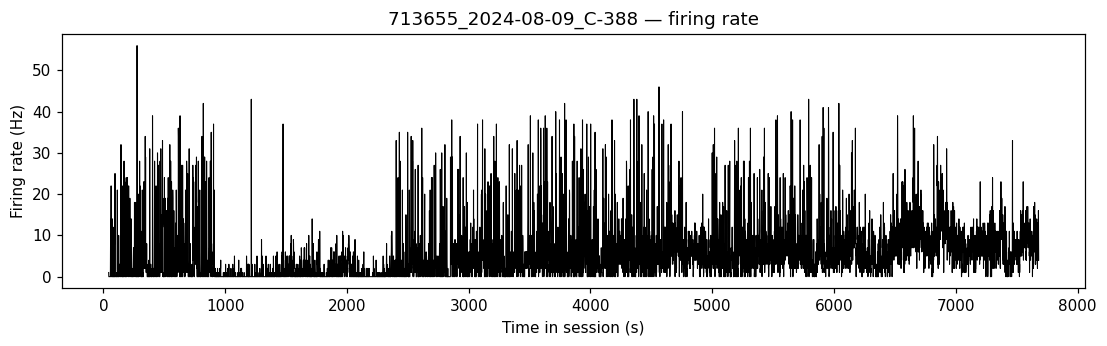

In [11]:
bin_times, rate_hz = firing_rate(spike_times, bin_size=1.0)

plt.figure(figsize=(12, 3))
plt.plot(bin_times, rate_hz, color='k', lw=0.7)
plt.xlabel('Time in session (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'{unit_id} — firing rate')
plt.show()

**Exercise:** change `bin_size` to `0.1` or `10.0` and re-run. How does changing the bin size change the plot?

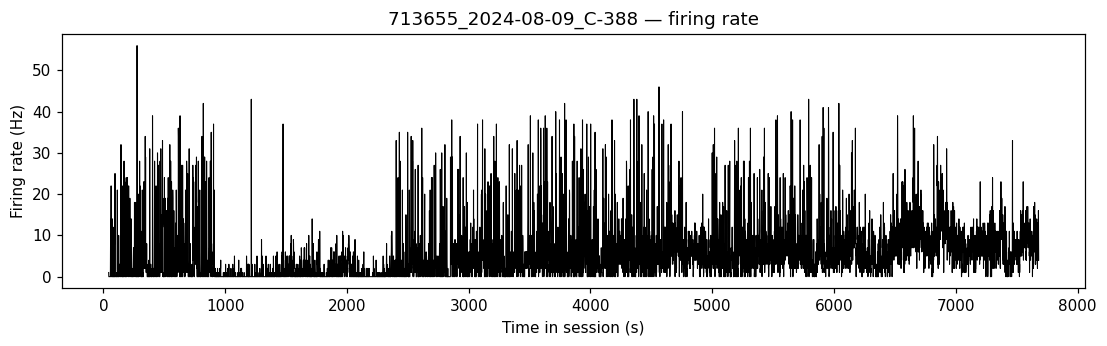

In [12]:
bin_times, rate_hz = firing_rate(spike_times, bin_size=1.0)   # change bin_size here

plt.figure(figsize=(12, 3))
plt.plot(bin_times, rate_hz, color='k', lw=0.7)
plt.xlabel('Time in session (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'{unit_id} — firing rate')
plt.show()

---
## 5. The `trials` table

Every stimulus presentation is one row in `trials`. The columns we care about in this tutorial are:

| Column Name | Definition |
|---|---|
| `stim_name` | reports the presented stimulus (`vis1`, `vis2`, `sound1`, `sound2`) |
| `stim_start_time` | when the stimulus was presented (s) |
| `rewarded_modality` | reports which modality was rewarded `vis` or `aud` |

In [22]:
trials = nwbfile.intervals['trials'].to_dataframe()
trials.head()

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,...,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,
0,2403.42415,2408.92875,2403.42415,2404.89204,2404.93261,2405.43261,2405.00879,2405.92623,2405.47583,2405.46553,...,False,False,False,False,False,True,False,False,False,False
1,2409.89623,2415.40125,2409.89623,2411.36411,2411.40501,2411.90501,2411.48088,2412.39832,2411.74797,2411.73257,...,False,False,False,False,False,True,False,False,False,False
2,2417.98632,2423.49098,2417.98632,2419.45423,2419.49515,2419.99515,2419.57102,2420.48843,2420.03805,2420.03365,...,False,False,False,False,False,True,False,False,False,False
3,2429.22911,2434.73372,2429.22911,2430.69701,2430.73779,2431.23779,2430.81378,2431.73118,2431.43094,2431.43076,...,False,False,False,False,False,True,False,False,False,False
4,2435.43427,2440.93889,2435.43427,2436.90215,2436.94313,2437.44313,2437.01895,2437.93632,2437.60277,2437.60187,...,False,False,False,False,False,True,False,False,False,False


In [23]:
# Get some summaries about the trial type counts

print(trials['stim_name'].value_counts(), '\n')
print(trials['rewarded_modality'].value_counts())

stim_name
vis1      125
sound1    118
sound2    109
vis2      108
catch      55
Name: count, dtype: int64 

rewarded_modality
vis    261
aud    254
Name: count, dtype: int64


### 5.1 Overlay stimulus onsets on the firing rate

Where in the session were visual vs. auditory targets presented?

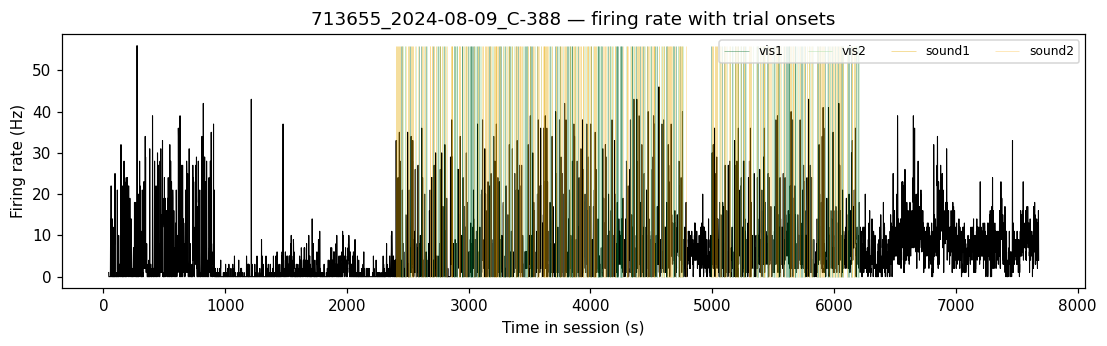

In [24]:
# Stimulus colors: greens for visual, yellows for auditory.
stim_colors = {
    'vis1': '#006d2c', 'vis2': '#a1d99b',
    'sound1': '#e6ab02', 'sound2': '#fec44f',
}

# Context colors: green for attend-visual, amber for attend-auditory.
context_colors = {
    'attend-vis': '#41ab5d',
    'attend-aud': '#fe9929',
}

plt.figure(figsize=(12, 3))
plt.plot(bin_times, rate_hz, color='k', lw=0.7)
for stim, color in stim_colors.items():
    onsets = trials.loc[trials['stim_name'] == stim, 'stim_start_time']
    plt.vlines(onsets, 0, rate_hz.max(),
               color=color, alpha=0.5, lw=0.5, label=stim)
plt.xlabel('Time in session (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'{unit_id} — firing rate with trial onsets')
plt.legend(loc='upper right', ncol=4, fontsize=8)
plt.show()

Here, we're plotting all the stimulus trials over the entire session. You might be able to tell that the firing rate increases with each auditory stimulus, a hint that this is an auditory-driven neuron. With hundreds of trials packed together, it's difficult to tell what this neuron responds to, so we need to **align neural activity to the stimulus onsets or events**. In the next section, we'll walk through how to create a PSTH.

---
## 6. Build a PSTH

A **peri-stimulus time histogram (PSTH)** aligns spikes to a common event across many trials, like the stimulus onsets, then averages across many events.  We'll build it one step at a time using `sound1` trials.

### 6.1 Pick the event times

In [25]:
# Get all the stimulus start times for sound1 trials.
sound1_onsets = trials.loc[trials['stim_name'] == 'sound1', 'stim_start_time'].to_numpy()

print(f'{len(sound1_onsets)} sound1 trials in this session')
print('first 5 onset times (s):', np.round(sound1_onsets[:5], 2))

118 sound1 trials in this session
first 5 onset times (s): [2404.93 2411.41 2419.5  2430.74 2436.94]


### 6.2 For one event, grab surrounding spikes and align to t = 0

For each event time `t0`, keep spikes in `[t0 − 0.5, t0 + 1.0]`, then subtract `t0`. Now the trial's spikes are measured *relative to onset* — t = 0 is when the stimulus started.

In [26]:
window = (-0.5, 1.0)   # 500 ms before to 1000 ms after stimulus onset

t0      = sound1_onsets[0]                                   # first sound1 onset
nearby  = spike_times[(spike_times >= t0 + window[0]) &
                      (spike_times <  t0 + window[1])]        # spikes inside the window
aligned = nearby - t0                                          # re-express relative to t0

print(f'Trial 0 onset          : {t0:.2f} s')
print(f'# spikes in the window : {len(nearby)}')
print(f'aligned times          : {aligned}')

Trial 0 onset          : 2404.93 s
# spikes in the window : 38
aligned times          : [0.06877767 0.07967756 0.08834415 0.14377693 0.15961011 0.16867669
 0.18900982 0.22407614 0.23224273 0.23894266 0.25274253 0.25904247
 0.29140881 0.32197518 0.33014177 0.34254164 0.34934158 0.37584132
 0.3910745  0.39920775 0.42957412 0.44334065 0.46714042 0.48400692
 0.49357349 0.5060067  0.52073989 0.52887314 0.57507269 0.62793883
 0.65110527 0.69703815 0.72000459 0.76130419 0.78853725 0.87903636
 0.9297692  0.9629022 ]


### 6.3 Repeat for every trial

Now repeat this process for  all 188 sound1 trials in this session. Then, plot each row as a raster plot aligned to the stimulus onset.

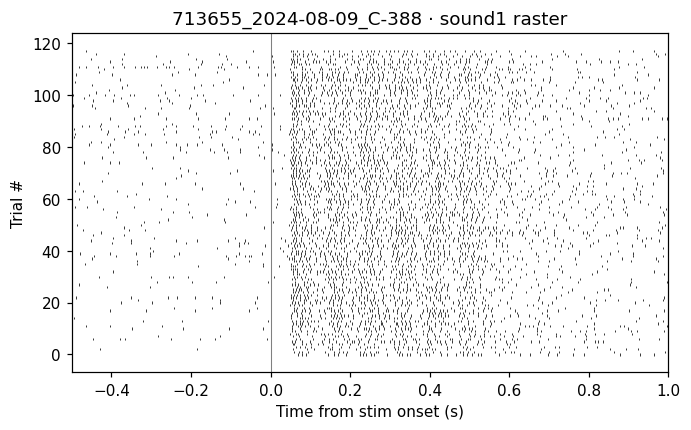

In [27]:
aligned_spikes = [] # create an empty list

for t0 in sound1_onsets:
    nearby  = spike_times[(spike_times >= t0 + window[0]) &
                          (spike_times <  t0 + window[1])]
    aligned = nearby - t0
    aligned_spikes.append(aligned)

plt.figure(figsize=(7, 4))
plt.eventplot(aligned_spikes, colors='k', linewidths=0.5, linelengths=0.9)
plt.axvline(0, color='0.5', lw=0.7)
plt.xlim(window)
plt.xlabel('Time from stim onset (s)')
plt.ylabel('Trial #')
plt.title(f'{unit_id} · sound1 raster')
plt.show()

### 6.4 Plot firing rate

From the aligned spike times across trials, calculate the average firing rate. First, count the number of spikes across trials in bins (e.g. 25ms). Divide by `n_trials x bin_width` to get the firing rate in Hz.

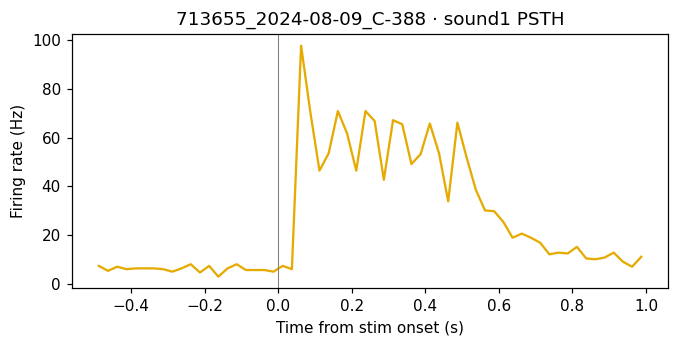

In [19]:
bin_size = 0.025
bins     = np.arange(window[0], window[1] + bin_size, bin_size)

spike_counts = np.zeros(len(bins) - 1)
for trial_spikes in aligned_spikes:
    spike_counts += np.histogram(trial_spikes, bins=bins)[0]

psth_rate    = spike_counts / (len(aligned_spikes) * bin_size)   # convert counts to Hz
time_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(7, 3))
plt.plot(time_centers, psth_rate, color=stim_colors['sound1'])
plt.axvline(0, color='0.5', lw=0.7)
plt.xlabel('Time from stim onset (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'{unit_id} · sound1 PSTH')
plt.show()

### 6.5 Wrap the steps into a reusable function

Now that we've walked through the steps of how to create a PSTH, we can collapse this into a few functions.

In [20]:
def generate_psth(spike_times, event_times, window=(-0.5, 1.0), bin_size=0.025):
    """Peri-stimulus time histogram.

    Returns
    -------
    time_centers : bin centers relative to each event (s)
    psth_rate    : firing rate averaged across events (Hz)
    """
    bins         = np.arange(window[0], window[1] + bin_size, bin_size)
    spike_counts = np.zeros(len(bins) - 1)
    for t0 in event_times:
        nearby = spike_times[(spike_times >= t0 + window[0]) &
                             (spike_times <  t0 + window[1])]
        spike_counts += np.histogram(nearby - t0, bins=bins)[0]
    psth_rate    = spike_counts / (len(event_times) * bin_size)
    time_centers = 0.5 * (bins[:-1] + bins[1:])
    return time_centers, psth_rate

---
## 7. PSTH for each stimulus

This neuron responds strongly to sound1 - what about other stimuli? Create a PSTH for each stimulus (vis1, vis2, sound1, sound2).

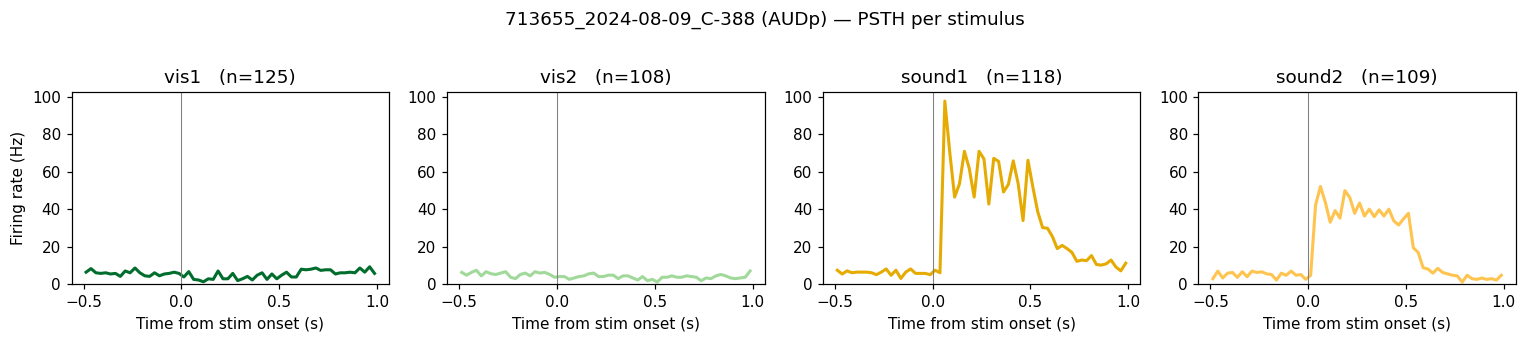

In [28]:
# First pass: compute a PSTH for each stimulus so we can pick a shared y-axis.
psths = []
for stim in ['vis1', 'vis2', 'sound1', 'sound2']:
    event_times             = trials.loc[trials['stim_name'] == stim, 'stim_start_time'].to_numpy()
    time_centers, psth_rate = generate_psth(spike_times, event_times)
    psths.append((stim, event_times, time_centers, psth_rate))

y_max = max(psth_rate.max() for _, _, _, psth_rate in psths)

# Second pass: plot each PSTH with the same y-limits.
plt.figure(figsize=(14, 3))

for i, (stim, event_times, time_centers, psth_rate) in enumerate(psths):
    plt.subplot(1, 4, i + 1)
    plt.plot(time_centers, psth_rate, color=stim_colors[stim], lw=2)
    plt.axvline(0, color='0.5', lw=0.7)
    plt.ylim(0, y_max * 1.05)
    plt.title(f'{stim}   (n={len(event_times)})')
    plt.xlabel('Time from stim onset (s)')
    if i == 0:
        plt.ylabel('Firing rate (Hz)')

plt.suptitle(f'{unit_id} ({area}) — PSTH per stimulus', y=1.02)
plt.tight_layout()
plt.show()

**Discuss** Is this neuron modality (visual or auditory) selective)? What else do you notice? Is that in line with what you expect for a neuron in primary auditory cortex?

---
## 8. Assess modality selectivity across units and brain areas.

Let's assess whether each unit is tuned to a particular modality. There are a few ways we can quantify this, but let's focus on a specific case where a neuron is **excited** by one of the stimuli (vis1, vis2, sound1, sound2) for now. We need to find whether the firing rate was significantly higher just after the stimulus compared to a baseline period before the stimulus.

So, we compare per-trial firing rates in two matched windows:

- **response**: 0 → 250 ms after onset
- **baseline**: 250 ms → 0 ms before onset

and run a paired t-test to evaluate significance.

In [29]:
def count_in_window(spike_times, event_times, t_start, t_end):
    """Number of spikes in [event + t_start, event + t_end) for each event."""
    lo = np.searchsorted(spike_times, event_times + t_start)
    hi = np.searchsorted(spike_times, event_times + t_end)
    return hi - lo


def is_responsive(spike_times, event_times,
                  response=(0.0, 0.25), baseline=(-0.25, 0.0), alpha=0.01):
    """True if evoked firing rate is significantly greater than baseline."""
    if len(event_times) < 5:
        return False, np.nan
    response_rates = count_in_window(spike_times, event_times, *response) / (response[1] - response[0])
    baseline_rates = count_in_window(spike_times, event_times, *baseline) / (baseline[1] - baseline[0])
    t_stat, p_value = stats.ttest_rel(response_rates, baseline_rates)
    return bool(t_stat > 0 and p_value < alpha), float(p_value)


# Try it on our unit for each stimulus
print(f'{unit_id} ({area}):')
for stim in ['vis1', 'vis2', 'sound1', 'sound2']:
    event_times = trials.loc[trials['stim_name'] == stim, 'stim_start_time'].to_numpy()
    responsive, p_value = is_responsive(spike_times, event_times)
    print(f'  {stim:>4}   responsive = {str(responsive):5s}   p = {p_value:.2g}')

713655_2024-08-09_C-388 (AUDp):
  vis1   responsive = False   p = 2.3e-05
  vis2   responsive = False   p = 0.14
  sound1   responsive = True    p = 9.7e-81
  sound2   responsive = True    p = 4.6e-66


The previous analysis confirms what we observed in the PSTH - this neuron is driven by both auditory stimuli and is not responsive to either visual stimulus.

**Discuss:** How would changing the time windows of the response and baseline we're comparing change the analysis?


### 8.1 Classify every neuron

Run the same test on every QC-pass unit, then bucket each one by *which* stimuli it responds to. The following function `classify_units` will apply the `is_responsive` function for every unit and stimulus type.

In [30]:
def classify_units(units_df, trials_df):
    stim_events = {
        stim: trials_df.loc[trials_df['stim_name'] == stim, 'stim_start_time'].to_numpy()
        for stim in ['vis1', 'vis2', 'sound1', 'sound2']
    }

    labels = []
    for _, unit_row in units_df[units_df['is_qc_pass']].iterrows():
        unit_spike_times = np.asarray(unit_row['spike_times'])

        excited = set()
        for stim, event_times in stim_events.items():
            if is_responsive(unit_spike_times, event_times)[0]:
                excited.add(stim)

        if not excited:
            label = 'none'
        elif excited == {'vis1', 'vis2'}:
            label = 'both visual'
        elif excited == {'sound1', 'sound2'}:
            label = 'both auditory'
        elif len(excited) == 1:
            label = f'{next(iter(excited))} only'
        else:
            label = 'mixed'

        labels.append({'unit_id':   unit_row['unit_id'],
                       'structure': unit_row['structure'],
                       'label':     label})

    return pd.DataFrame(labels)


classification = classify_units(units, trials)
classification['label'].value_counts()

,count
label,
none,796
mixed,142
both auditory,80
vis1 only,50
vis2 only,40
sound2 only,28
both visual,28
sound1 only,21


Now we have a table with a row for every unit and the brain structure and classification label.

In [31]:
classification

,unit_id,structure,label
0,713655_2024-08-09_A-3,AV,none
1,713655_2024-08-09_A-8,AV,vis2 only
2,713655_2024-08-09_A-11,AV,mixed
3,713655_2024-08-09_A-19,AV,mixed
4,713655_2024-08-09_A-35,AD,none
...,...,...,...
1180,713655_2024-08-09_F-819,MOs,mixed
1181,713655_2024-08-09_F-823,MOs,none
1182,713655_2024-08-09_F-826,MOs,none
1183,713655_2024-08-09_F-828,MOs,none


### 8.2 Response profiles by brain area

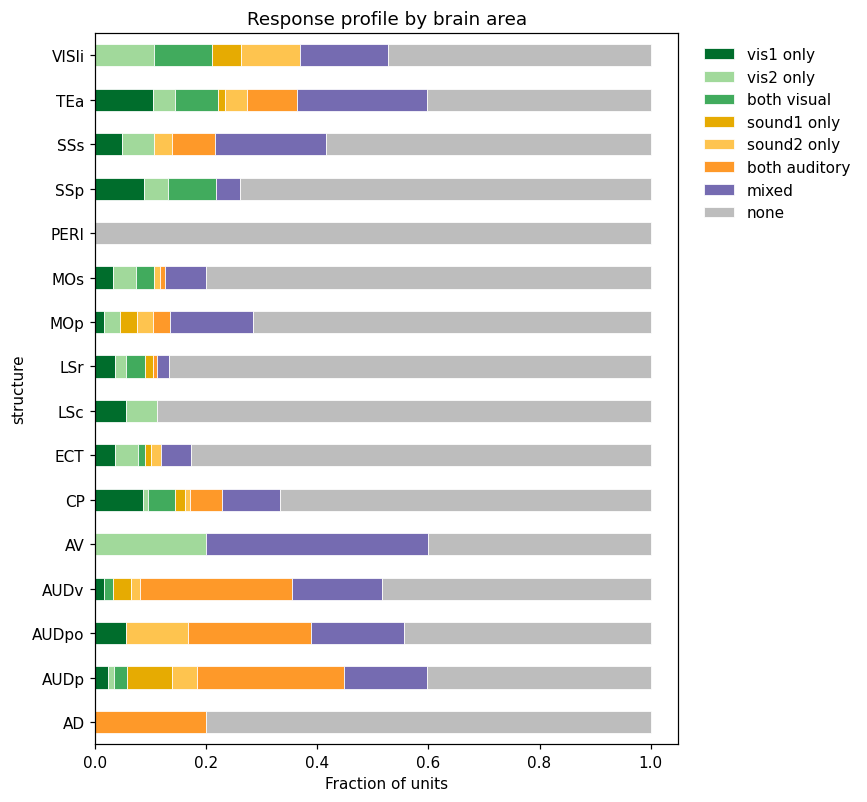

In [32]:
label_order = [
    'vis1 only', 'vis2 only', 'both visual',
    'sound1 only', 'sound2 only', 'both auditory',
    'mixed', 'none',
]

label_colors = [
    '#006d2c', '#a1d99b', '#41ab5d',   # visual categories (greens)
    '#e6ab02', '#fec44f', '#fe9929',   # auditory categories (yellows/ambers)
    '#756bb1', '#bdbdbd',              # mixed (purple), none (gray)
]

# Fraction of each label per structure (keep areas with ≥ 3 units).
by_area = (classification.groupby(['structure', 'label']).size()
                         .unstack(fill_value=0))
by_area = by_area.loc[by_area.sum(axis=1) >= 3]
by_area = by_area.div(by_area.sum(axis=1), axis=0)
by_area = by_area.reindex(columns=label_order, fill_value=0)

by_area.plot(kind='barh', stacked=True,
             figsize=(8, 0.4 * len(by_area) + 1),
             color=label_colors,
             edgecolor='white', linewidth=0.5)
plt.xlabel('Fraction of units')
plt.title('Response profile by brain area')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

Auditory areas (`AUDp`, `AUDv`) are dominated by yellow bars — auditory-responsive units. Visual areas are dominated by green bars. Higher-order and association areas often show a broader palette, including purple bars for units driven by *both* modalities.

---
## 9. Does attention change the response?

So far we've treated every stimulus as the same, but remember that the animal was switching between two contexts:

- **attend-visual** blocks — a visual target (`vis1`) is rewarded
- **attend-auditory** blocks — an auditory target (`sound1`) is rewarded

So, although the same sound1 stimulus is presented in both both blocks, in one block it is associated with a reward and in another it is not. If attention matters, the neuron should respond differently depending on which modality the animal is currently attending. Let's compare responses between these two different blocks.

### 9.1 Split `sound1` trials by context

Take all `sound1` trials, separate them into "attend-vis" and "attend-aud" subsets and plot a PSTH.

sound1 in attend-aud blocks (attended)   : 64
sound1 in attend-vis blocks (unattended) : 54


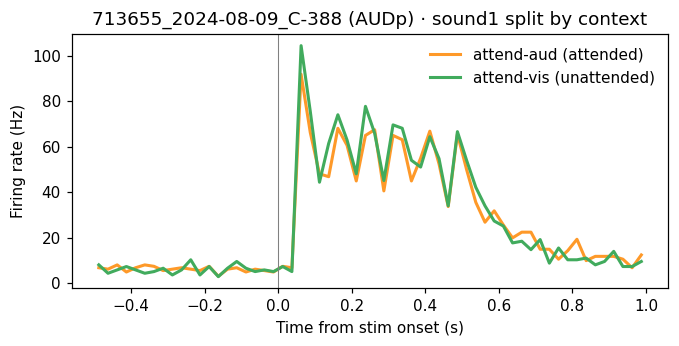

In [33]:
is_sound1         = trials['stim_name'] == 'sound1'
sound1_attended   = trials.loc[is_sound1 & (trials['rewarded_modality'] == 'aud'),
                               'stim_start_time'].to_numpy()
sound1_unattended = trials.loc[is_sound1 & (trials['rewarded_modality'] == 'vis'),
                               'stim_start_time'].to_numpy()

print(f'sound1 in attend-aud blocks (attended)   : {len(sound1_attended)}')
print(f'sound1 in attend-vis blocks (unattended) : {len(sound1_unattended)}')

time_centers_att, rate_att = generate_psth(spike_times, sound1_attended)
time_centers_un,  rate_un  = generate_psth(spike_times, sound1_unattended)

plt.figure(figsize=(7, 3))
plt.plot(time_centers_att, rate_att, color=context_colors['attend-aud'],
         lw=2, label='attend-aud (attended)')
plt.plot(time_centers_un,  rate_un,  color=context_colors['attend-vis'],
         lw=2, label='attend-vis (unattended)')
plt.axvline(0, color='0.5', lw=0.7)
plt.xlabel('Time from stim onset (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'{unit_id} ({area}) · sound1 split by context')
plt.legend(frameon=False)
plt.show()

For our AUDp unit, the responses in both contexts (attend-vis and attend-aud) look very similar. The neuron is **context-invariant**. This is in line with what we expect for primary auditory cortex, which faithfully encodes the auditory stimulus regardless of attentional state.

Attention effects are more likely to appear in *downstream* areas where sensory input meets task demand. To find those neurons, we need to quantify the effect of attention on the stimulus-driven responses.

---
## 10. Attention Modulation Index (AMI)

Let's create a formula that quantifies the attention effect, which we'll call the attention modulation index (AMI). We'll collapse the stimulus-driven responses to a single number that we can compare across units. Here is the logic:

### 1. define a response window

Here, we'll use the first **250ms** after stimulus onset, which is long enough to capture a sensory-driven response but short enough to avoid mixing in later trial events.

### 2. compute mean firing rates during attended and unattended blocks

- $r_\mathrm{attended}$ — average across trials where the presented modality **is** rewarded
- $r_\mathrm{unattended}$ — average across trials where it **is not** rewarded

### 3. compare mean firing rates across attended and unattended blocks

We want a score that is:
- **positive** when the neuron fires more on attended trials, **negative** when it fires less,
- **zero** when the two rates are equal,
- on the **same scale** for a low firing (1-2Hz) as for a high firing one (50-100Hz)

Dividing the difference by the sum does exactly that:

$$
\mathrm{AMI} \;=\; \frac{r_\mathrm{attended} \;-\; r_\mathrm{unattended}}
                        {r_\mathrm{attended} \;+\; r_\mathrm{unattended}}
$$


| AMI value | What it means |
|---|---|
| **> 0** | response **enhanced** by attention |
| **< 0** | response **suppressed** by attention |
| **≈ 0** | context-invariant — attention doesn't matter |

### 10.1 Compute AMI for our AUDp unit on `sound1` trials


In [34]:
# For sound1 trials, the animal is "attending" whenever the auditory modality
# is rewarded. We already split those onsets into attended vs unattended.

response_window = (0.0, 0.25)   # first 250 ms after onset
window_duration = response_window[1] - response_window[0]

# Mean firing rate in the response window on each set of trials.
rate_attended   = count_in_window(spike_times, sound1_attended,   *response_window).mean() / window_duration
rate_unattended = count_in_window(spike_times, sound1_unattended, *response_window).mean() / window_duration

# Plug into the AMI formula.
ami = (rate_attended - rate_unattended) / (rate_attended + rate_unattended)

print('sound1 response window (0–250 ms):')
print(f'  attended   (animal listening) = {rate_attended:.1f} Hz')
print(f'  unattended (animal watching)  = {rate_unattended:.1f} Hz')
print(f'  AMI                           = {ami:+.3f}')

sound1 response window (0–250 ms):
  attended   (animal listening) = 50.6 Hz
  unattended (animal watching)  = 56.1 Hz
  AMI                           = -0.052


---
## 11. Which neurons *are* modulated by attention?

For our AUDp unit, `AMI ≈ 0`. One hypothesis is that the primary auditory cortex sits close to the sensory input — it reports the sound whether the animal cares or not. Attention effects are more likely to appear in downstream areas: higher sensory cortex, association cortex, motor cortex.

Let's scale up our analysis to include all units across all brain areas.

1. Compute AMI for **every QC-pass unit × every stimulus** where the unit actually responds.
2. Keep only the stimulus responses where the attended vs unattended difference is statistically significant
3. Sort the responses by the size of the attention effect ( `|AMI|` ).

### 11.1 Wrap the AMI calculation into a function

Same formula as above but backed as a function in which we pass any (unit, stimulus) pair. Also returns a p-value for the attended-vs-unattended difference to assess significance.


In [35]:
def attention_modulation_index(spike_times, trials_df, stim_name,
                               window=(0.0, 0.25)):
    """Compute AMI for one stimulus type.

    Returns a dict with:
      ami             – (attended − unattended) / (attended + unattended), [−1, +1]
      rate_attended   – mean firing rate on attended trials (Hz)
      rate_unattended – mean firing rate on unattended trials (Hz)
      p_value         – attended-vs-unattended difference (Welch t-test)
    """
    # For a visual stimulus, "attended" = attend-visual blocks; for auditory, vice versa.
    modality = 'vis' if stim_name.startswith('vis') else 'aud'

    # Split this stimulus's trials by which modality is currently rewarded.
    stim_trials        = trials_df[trials_df['stim_name'] == stim_name]
    attended_onsets    = stim_trials.loc[stim_trials['rewarded_modality'] == modality,
                                         'stim_start_time'].to_numpy()
    unattended_onsets  = stim_trials.loc[stim_trials['rewarded_modality'] != modality,
                                         'stim_start_time'].to_numpy()

    # Per-trial firing rate in the response window, for each set of trials.
    window_duration     = window[1] - window[0]
    rates_attended      = count_in_window(spike_times, attended_onsets,   *window) / window_duration
    rates_unattended    = count_in_window(spike_times, unattended_onsets, *window) / window_duration

    # Aggregate → AMI + significance test.
    rate_attended       = rates_attended.mean()
    rate_unattended     = rates_unattended.mean()
    ami                 = (rate_attended - rate_unattended) / (rate_attended + rate_unattended + 1e-9)
    _, p_value          = stats.ttest_ind(rates_attended, rates_unattended, equal_var=False)

    return {'ami': ami,
            'rate_attended':rate_attended,'p_value': p_value,
            'rate_unattended': rate_unattended}

In [36]:
# For every QC-pass unit × every stimulus it responds to, compute the AMI.
records = []

for _, unit_row in units[units['is_qc_pass']].iterrows():
    unit_spike_times = np.asarray(unit_row['spike_times'])

    for stim_name in ['vis1', 'vis2', 'sound1', 'sound2']:
        event_times = trials.loc[trials['stim_name'] == stim_name, 'stim_start_time'].to_numpy()

        if not is_responsive(unit_spike_times, event_times)[0]:
            continue

        result = attention_modulation_index(unit_spike_times, trials, stim_name)
        records.append({
            'unit_id':       unit_row['unit_id'],
            'structure':     unit_row['structure'],
            'stim':          stim_name,
            'attended_Hz':   result['rate_attended'],
            'unattended_Hz': result['rate_unattended'],
            'ami':           result['ami'],
            'p_value':       result['p_value'],
        })

attn = pd.DataFrame(records)
print(f'{len(attn)} (unit, stimulus) pairs where the unit responds to the stimulus')
attn.head()

778 (unit, stimulus) pairs where the unit responds to the stimulus


,unit_id,structure,stim,attended_Hz,unattended_Hz,ami,p_value
0,713655_2024-08-09_A-8,AV,vis2,6.618182,5.811321,0.064915,0.394390
1,713655_2024-08-09_A-11,AV,vis2,7.127273,5.962264,0.089003,0.247729
2,713655_2024-08-09_A-11,AV,sound2,4.370370,5.527273,-0.116887,0.212857
3,713655_2024-08-09_A-19,AV,vis1,15.500000,14.113208,0.046830,0.385648
4,713655_2024-08-09_A-19,AV,vis2,15.490909,16.377358,-0.027816,0.657346


### Reading the AMI table

Each row above is one **(neuron, stimulus)** pair:

| Column | Definition |
|---|---|
| `stim` | Which stimulus this AMI was computed for. A neuron that responds to all four stimuli contributes four rows. |
| `attended_Hz` | Mean firing rate on trials of `stim` when the animal was attending to that modality (e.g. for `sound1`, attend-auditory blocks). |
| `unattended_Hz` | Mean firing rate on trials of `stim` when the animal was attending to the other modality. |
| `ami` | The Attention Modulation Index, [−1, +1]. |
| `p_value` | outcome of Welch's t-test |

### 11.2 Filter for significantly modulated neurons and sort by size of the effect

Let's consider neurons that are significantly modulated by attention. A few things to filter out and sort by:

1. The attended-vs-unattended difference is just trial-to-trial **noise**: filter by `p_value < 0.001`.
2. Both firing rates are so **small** that AMI is unstable: filter by `attended_Hz + unattended_Hz > 10`.

Then sort by the *size* of the AMI ( `|AMI|` ) to consider both suppressive and enhancive effects.

In [37]:
# Filter for significant and substantial attention effects
significant = attn[
    (attn['p_value'] < 0.001) &
    (attn['attended_Hz'] + attn['unattended_Hz'] > 10)
].copy()

# Sort by the absolute value of the AMI
significant['abs_ami'] = significant['ami'].abs()
significant = significant.sort_values('abs_ami', ascending=False)

print(f'{len(significant)} pairs have a significant, substantial attention effect')
significant.head(10)


89 pairs have a significant, substantial attention effect


,unit_id,structure,stim,attended_Hz,unattended_Hz,ami,p_value,abs_ami
434,713655_2024-08-09_C-640,TEa,sound1,0.500000,9.777778,-0.902703,4.903837e-13,0.902703
757,713655_2024-08-09_F-432,MOs,vis2,1.309091,10.037736,-0.769259,1.643240e-13,0.769259
627,713655_2024-08-09_E-209,MOp,sound2,11.111111,2.036364,0.690227,3.028892e-11,0.690227
518,713655_2024-08-09_C-964,TEa,sound2,9.407407,1.745455,0.686994,7.299260e-12,0.686994
432,713655_2024-08-09_C-634,TEa,sound2,12.666667,2.545455,0.665339,2.272799e-10,0.665339
80,713655_2024-08-09_B-160,SSs,sound2,23.037037,4.945455,0.646532,5.697907e-11,0.646532
626,713655_2024-08-09_E-209,MOp,sound1,17.125000,3.925926,0.627007,8.478560e-16,0.627007
431,713655_2024-08-09_C-634,TEa,sound1,10.625000,2.444444,0.625930,5.866426e-08,0.625930
519,713655_2024-08-09_C-965,TEa,sound1,2.062500,8.222222,-0.598920,7.622755e-08,0.598920
438,713655_2024-08-09_C-645,TEa,sound1,2.875000,9.481481,-0.534657,1.288917e-08,0.534657


### Discuss

Pick out a few units - what do you notice?

- **`E-209`** in `MOp` (primary motor cortex) shows up near the top on **both** `sound1` and `sound2` — its firing rate is 4–5× higher on attended trials than unattended ones for auditory stimuli.
- Notice that `E-209`'s `sound2` row (AMI = +0.69) ranks *above* its `sound1` row (AMI = +0.63), even though the neuron fires *more* on `sound1` than on `sound2` (17 Hz vs 11 Hz when attended). That's because **AMI measures the *relative* effect of attention, not the absolute response strength**: for `sound2`, the unattended rate is low (2 Hz), so the ratio between attended and unattended is even bigger.
- **`TEa`** (temporal association area) units come up frequently on the list - this is a downstream area that mixes sensory input with task-relevant information.

### 11.3 Unit`E-209` in MOp

Let's look at an example - get the unit table data for `E-209` and plot PSTHs across the 8 conditions (4 stimuli: vis1, vis2, sound1, sound2; 2 contexts: attend-vis, attend-aud).

In [38]:
unit_id     = '713655_2024-08-09_E-209'
unit_row    = units.loc[units['unit_id'] == unit_id].iloc[0]
area        = unit_row['structure']
spike_times = np.asarray(unit_row['spike_times'])

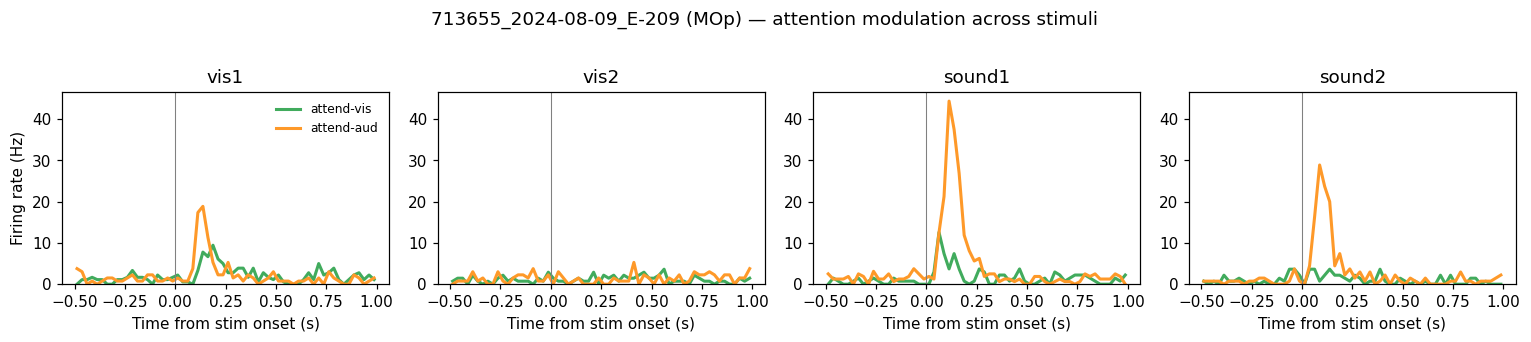

In [39]:
# First pass: compute PSTHs for each (stimulus, context) so we can share a y-axis.
panels = []
for stim in ['vis1', 'vis2', 'sound1', 'sound2']:
    is_stim           = trials['stim_name'] == stim
    attend_vis_onsets = trials.loc[is_stim & (trials['rewarded_modality'] == 'vis'),
                                   'stim_start_time'].to_numpy()
    attend_aud_onsets = trials.loc[is_stim & (trials['rewarded_modality'] == 'aud'),
                                   'stim_start_time'].to_numpy()
    vis_psth = generate_psth(spike_times, attend_vis_onsets) if len(attend_vis_onsets) else None
    aud_psth = generate_psth(spike_times, attend_aud_onsets) if len(attend_aud_onsets) else None
    panels.append((stim, vis_psth, aud_psth))

# Find the tallest peak across all panels.
y_max = 0
for _, vis_psth, aud_psth in panels:
    if vis_psth is not None:
        y_max = max(y_max, vis_psth[1].max())
    if aud_psth is not None:
        y_max = max(y_max, aud_psth[1].max())

# Second pass: plot each panel with the same y-limits.
plt.figure(figsize=(14, 3))

for i, (stim, vis_psth, aud_psth) in enumerate(panels):
    plt.subplot(1, 4, i + 1)
    if vis_psth is not None:
        time_centers, rate = vis_psth
        plt.plot(time_centers, rate, color=context_colors['attend-vis'],
                 lw=2, label='attend-vis')
    if aud_psth is not None:
        time_centers, rate = aud_psth
        plt.plot(time_centers, rate, color=context_colors['attend-aud'],
                 lw=2, label='attend-aud')

    plt.axvline(0, color='0.5', lw=0.7)
    plt.ylim(0, y_max * 1.05)
    plt.title(stim)
    plt.xlabel('Time from stim onset (s)')
    if i == 0:
        plt.ylabel('Firing rate (Hz)')
        plt.legend(frameon=False, fontsize=8, loc='upper right')

plt.suptitle(f'{unit_id} ({area}) — attention modulation across stimuli', y=1.02)
plt.tight_layout()
plt.show()

### Interpreting the plot above

Each panel shows the neural activity responses to each stimulus (`vis1`, `vis2`, `sound1`, `sound2`). The two lines separate the *context* the animal is in, or which stimulus type was rewarded (auditory or visual).

---
## 12. Wrap up

### Summary

- Primary sensory neurons (like `C-388` in AUDp) fire in response to auditory stimuli and are context invariant
- Downstream neurons in higher-order and motor areas (like `E-209` in MOp) respond much more strongly to the *same* sensory input when the animal is attending to it.

### Discussion

1. Why might a **primary auditory** neuron *not* care about attention, while a **motor-cortex** neuron with an auditory response *does*? Think about what each area is "for" in the task.
2. Our AMI collapses the entire response window down to one number. Where inside a trial (early vs late after onset) would you expect the attention effect to be strongest, and why?
3. Suppose the animal moves more during attend-auditory blocks than during attend-visual blocks. How could that inflate a positive AMI? What would you plot to argue the effect is really *attention* and not just *arousal* or *movement*?
4. `A-142` (also in MOp) has a large **negative** AMI on auditory stimuli — it fires *less* when the animal is attending to sound. Can you think of a reason a task-relevant neuron might be suppressed rather than enhanced?
